# Pubmat Checker — Testing Notebook

Notebook for manually testing each check in `checker.py`.

| Function | Runs for | Level |
|---|---|---|
| `logo_report()` | All | error |
| `check_logo_order()` | All | error |
| `check_pubmat_quality()` | All | error |
| `check_watermark()` | news, opportunity, holiday, other | error |
| `check_readability()` | All except photo | error |
| `check_spelling_on_image()` | All except photo | **warning** |
| `check_sgd()` | advisory, resolution | error |
| `check_photo_quality()` | photo | **warning** |
| `generate_report()` | Full pipeline | — |

*Error: if check fails, overall result is FAIL* \
*Warning: if check fails, overall result is PASS (with issues)*

**OCR reliability gate:** if readability fails or no text is detected, watermark is set to FAIL (error, manual review required) and spelling is skipped (warning).

## Imports and Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import types
import torch
import pprint
pp = pprint.PrettyPrinter(indent=2)

from ultralytics import YOLO

from checker import (
    _run_doctr,
    _extract_ocr_data,
    _mask_regions,
    _get_logo_boxes_abs,
    check_watermark,
    check_readability,
    check_pubmat_quality,
    check_sgd,
    check_photo_quality,
    check_logo_order,
    check_spelling_on_image,
    logo_report,
    generate_report,
    load_spell_checker,
    SPELL_WORD_LISTS,
    WATERMARK_HANDLES,
)


## Load Test Image and YOLO Model

In [2]:
IMAGE_PATH = 'test_set/images/test_7.jpg'
MODEL_PATH = '../training/runs/detect/tuned_model_v2/weights/best.pt'

image = cv2.imread(IMAGE_PATH)
assert image is not None, f'Failed to load image: {IMAGE_PATH}'

h, w = image.shape[:2]
print(f'Image loaded: {w}x{h} px — {image.dtype}')

logo_model = YOLO(MODEL_PATH)
print('YOLO model loaded.')


Image loaded: 1080x1350 px — uint8
YOLO model loaded.


## Logo Detection

`logo_report()` runs YOLO on the original image. NYC and BP are always required; SK/YORP only when listed in `collaborators`.


0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 64.5ms
Speed: 22.4ms preprocess, 64.5ms inference, 20.1ms postprocess per image at shape (1, 3, 800, 640)


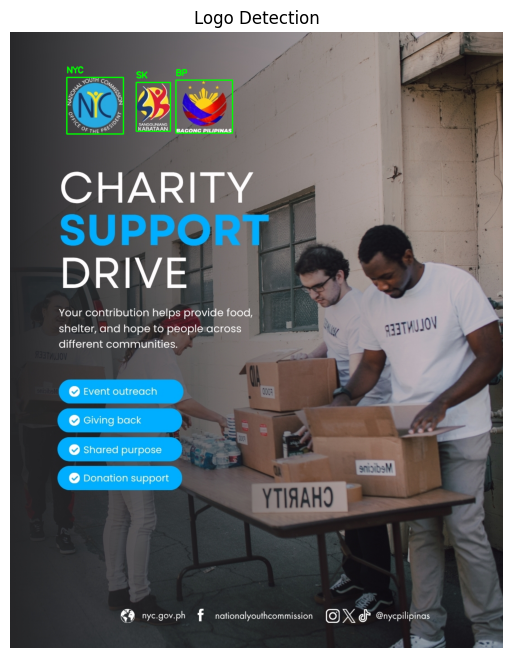

{ 'details': { 'logos': [ { 'confidence': 0.975,
                            'detected': True,
                            'level': 'error',
                            'logo': 'NYC',
                            'pass': True,
                            'remark': 'OK',
                            'status': 'Correct'},
                          { 'confidence': 0.949,
                            'detected': True,
                            'level': 'error',
                            'logo': 'BP',
                            'pass': True,
                            'remark': 'OK',
                            'status': 'Correct'},
                          { 'confidence': 0.938,
                            'detected': True,
                            'level': 'error',
                            'logo': 'SK',
                            'pass': True,
                            'remark': 'OK',
                            'status': 'Correct'}]},
  'label': 'All logos OK',
  'level': 'e

In [3]:
logo_result, detected, annotated_img = logo_report(
    image, model=logo_model, conf_threshold=0.8, collaborators=['sk']
)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title('Logo Detection')
plt.axis('off')
plt.show()

pp.pprint(logo_result)


## OCR

Logo boxes are masked on the **original image** (not the annotated one) before running docTR. This prevents YOLO annotation artifacts from affecting OCR.

The watermark strip is intentionally **not** masked here — it's needed for `check_watermark()`.

Content words/boxes/confidences exclude watermark handle words for use in readability and spelling.

In [4]:
# Mask logo boxes on the original image — NOT img_annotated
logo_boxes_abs = _get_logo_boxes_abs(detected, image.shape)
masked_image   = _mask_regions(image, logo_boxes_abs)

# Single OCR pass
ocr_words, ocr_confidences, ocr_boxes = _extract_ocr_data(_run_doctr(masked_image))

# Filter out watermark handle words for body content checks
filtered = [
    (w, b, c) for w, b, c in zip(ocr_words, ocr_boxes, ocr_confidences)
    if w.lower() not in WATERMARK_HANDLES
]
content_words       = [f[0] for f in filtered]
content_boxes       = [f[1] for f in filtered]
content_confidences = [f[2] for f in filtered]

print(f'Total OCR words : {len(ocr_words)}')
print(f'Content words   : {len(content_words)} (watermark handles excluded)')
print(f'Avg confidence  : {round(sum(content_confidences)/len(content_confidences), 3) if content_confidences else 0}')
print(f'Sample words    : {content_words[:20]}')


Total OCR words : 33
Content words   : 30 (watermark handles excluded)
Avg confidence  : 0.927
Sample words    : ['CHARITY', 'SUPPOR', 'DRIVE', 'Your', 'contribution', 'helps', 'provide', 'food,', 'shelter,', 'and', 'hope', 'to', 'people', 'across', 'different', 'communities.', 'Event', 'outreach', '0001', 'Giving']


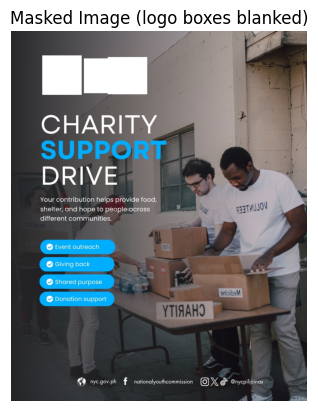

In [5]:
# View masked image — logo boxes should be white, watermark strip should be visible
plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
plt.title('Masked Image (logo boxes blanked)')
plt.axis('off')
plt.show()


In [6]:
import pandas as pd
df_ocr = pd.DataFrame({'word': ocr_words, 'conf': ocr_confidences,
                        'y0': [b[1] for b in ocr_boxes]})
df_ocr['zone'] = df_ocr['y0'].apply(lambda y: 'watermark strip' if y >= 0.90 else 'content')
display(df_ocr)


,word,conf,y0,zone
0,CHARITY,0.980344,0.231445,content
1,SUPPOR,0.999099,0.294922,content
2,DRIVE,0.898886,0.363281,content
3,Your,0.986989,0.447266,content
4,contribution,0.876451,0.447266,content
5,helps,0.999297,0.447266,content
6,provide,0.999541,0.446289,content
7,"food,",0.997382,0.447266,content
8,"shelter,",0.994038,0.471680,content
9,and,0.993822,0.473633,content


## Check Watermark

Fuzzy-matches the three NYC handles against OCR words in the bottom 15% of the image (`y0 >= 0.85`).

Uses `ocr_words`/`ocr_boxes` directly (not `content_words`) since watermark words were intentionally kept in the OCR output.

The fallback (no precomputed words) crops the bottom 15% and runs a fresh docTR pass.

In [7]:
# Bottom 15% words from the shared OCR pass
bottom_pairs = [(w, b) for w, b in zip(ocr_words, ocr_boxes) if b[1] >= 0.85]
wm_words = [p[0] for p in bottom_pairs]
wm_boxes = [p[1] for p in bottom_pairs]

print(f'Words in bottom 15%: {wm_words}')

wm_result, wm_boxes_abs = check_watermark(image, precomputed_words=wm_words, precomputed_boxes=wm_boxes)
pp.pprint(wm_result)


Words in bottom 15%: ['nyc.gov.ph', 'f', 'nationalyouthcommission', 'O', 'X', '@nycpilipinas']
{ 'details': {},
  'detected': ['nyc.gov.ph', 'nationalyouthcommission', '@nycpilipinas'],
  'label': 'Watermark OK',
  'level': 'error',
  'missing': [],
  'pass': True,
  'remark': 'OK'}


In [8]:
# Fallback: no precomputed data — crops bottom strip and re-runs docTR internally
wm_fallback, _ = check_watermark(image)
print('Fallback result:')
pp.pprint(wm_fallback)

# Both results should agree
print(f'\nPrecomputed pass: {wm_result["pass"]}  |  Fallback pass: {wm_fallback["pass"]}')
if wm_result['pass'] != wm_fallback['pass']:
    print('WARNING: results disagree — bottom strip may have been affected by masking or annotation.')


Fallback result:
{ 'details': {},
  'detected': ['nyc.gov.ph', 'nationalyouthcommission', '@nycpilipinas'],
  'label': 'Watermark OK',
  'level': 'error',
  'missing': [],
  'pass': True,
  'remark': 'OK'}

Precomputed pass: True  |  Fallback pass: True


## Check Readability

Uses `content_confidences` (watermark words excluded) — not raw `ocr_confidences`.

Threshold is post-type dependent: 0.70 for news/advisory/quotes/resolution/opportunity, 0.50 for holiday/other.

In [9]:
threshold = 0.70  # change to match the post type being tested
readability = check_readability(content_confidences, threshold=threshold)
pp.pprint(readability)

# OCR reliability gate — same logic used in generate_report()
ocr_unreliable = not readability['pass'] or len(content_words) == 0
print(f'\nocr_unreliable: {ocr_unreliable}')
if ocr_unreliable:
    print('  → watermark check will be set to FAIL (manual review required)')
    print('  → spelling check will be skipped')


{ 'details': {'average_confidence': 0.927, 'num_words': 30},
  'label': 'Readable',
  'level': 'error',
  'pass': True,
  'remark': 'Average OCR confidence: 0.927'}

ocr_unreliable: False


## Check Spelling

**Warning-level check** — spelling errors do not cause an overall FAIL.

Uses `content_words` and `content_boxes` (watermark words excluded). Should only run when `ocr_unreliable` is False — if OCR is unreliable, `generate_report()` skips this check automatically.

{ 'details': { 'errors': [ { 'box_abs': (108, 398, 522, 487),
                             'suggestions': ['supper', 'support'],
                             'word': 'SUPPOR'},
                           { 'box_abs': (761, 941, 841, 970),
                             'suggestions': [],
                             'word': 'enibibeM'},
                           { 'box_abs': (554, 996, 708, 1044),
                             'suggestions': [],
                             'word': 'YTIAAHO'}]},
  'label': '3 spelling error(s) found',
  'level': 'warning',
  'pass': False,
  'remark': 'SUPPOR, enibibeM, YTIAAHO'}


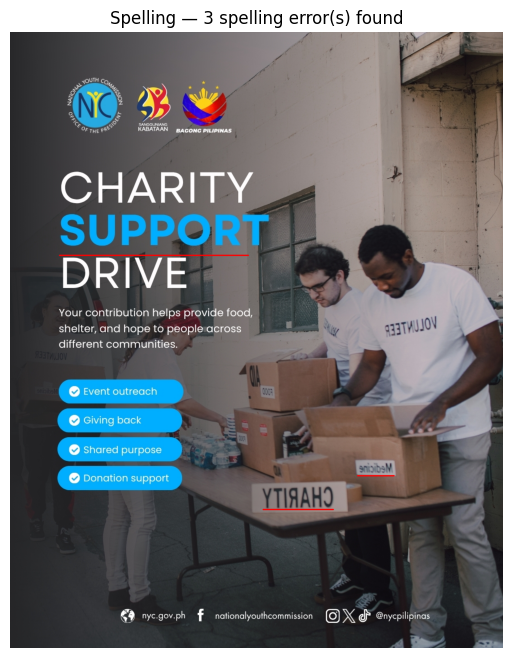

In [10]:
spell = load_spell_checker(SPELL_WORD_LISTS)

if ocr_unreliable:
    print('OCR unreliable — spelling check skipped (matches generate_report() behavior)')
else:
    annotated_spell, spell_result = check_spelling_on_image(
        image, content_words, content_boxes, spell
    )
    pp.pprint(spell_result)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(annotated_spell, cv2.COLOR_BGR2RGB))
    plt.title(f'Spelling — {spell_result["label"]}')
    plt.axis('off')
    plt.show()


## Check Pubmat Quality

Runs for all post types. Checks resolution ≥ 1080×1080, blur variance ≥ 50 (Laplacian), contrast std ≥ 30.

In [11]:
quality = check_pubmat_quality(image)
pp.pprint(quality)


{ 'details': { 'Blur Metric': np.float64(667.0),
               'Contrast Metric': np.float64(47.7),
               'Resolution': '1080x1350'},
  'label': 'Pubmat quality OK',
  'level': 'error',
  'pass': True,
  'remark': 'OK'}


## Check SGD

Applied to: advisory, resolution. Uses whole-word regex `\bsgd\b` — partial matches like `msgd` or `sgds` do not count.

In [12]:
# Unit tests
test_cases = [
    (['Pursuant', 'to', 'SGD', 'No.', '123'],  True),
    (['sgd', 'approved', 'by', 'the', 'board'], True),
    (['no', 'relevant', 'keyword', 'here'],      False),
    (['msgd', 'resolution', 'passed'],           False),
    (['sgds', 'are', 'required'],                False),
]

print('check_sgd() unit tests:')
all_ok = True
for words, expected in test_cases:
    result = check_sgd(words)
    ok = result['pass'] == expected
    if not ok: all_ok = False
    status = '✓' if ok else '✗'
    print(f'  {status} {words} → pass={result["pass"]} (expected {expected})')
print('All tests passed!' if all_ok else 'Some tests FAILED.')


check_sgd() unit tests:
  ✓ ['Pursuant', 'to', 'SGD', 'No.', '123'] → pass=True (expected True)
  ✓ ['sgd', 'approved', 'by', 'the', 'board'] → pass=True (expected True)
  ✓ ['no', 'relevant', 'keyword', 'here'] → pass=False (expected False)
  ✓ ['msgd', 'resolution', 'passed'] → pass=False (expected False)
  ✓ ['sgds', 'are', 'required'] → pass=False (expected False)
All tests passed!


In [13]:
# Run against actual OCR output from the loaded image
sgd_result = check_sgd(ocr_words)
pp.pprint(sgd_result)


{ 'details': {},
  'label': 'SGD MISSING',
  'level': 'error',
  'pass': False,
  'remark': 'Use SGD for resolutions/advisories'}


## Check Photo Quality

**Warning-level check** — applied to `photo` post type only. Checks resolution ≥ 1080×1080, brightness ≥ 60, colour saturation (checks top 80% of image to exclude the branded template bar at the bottom).

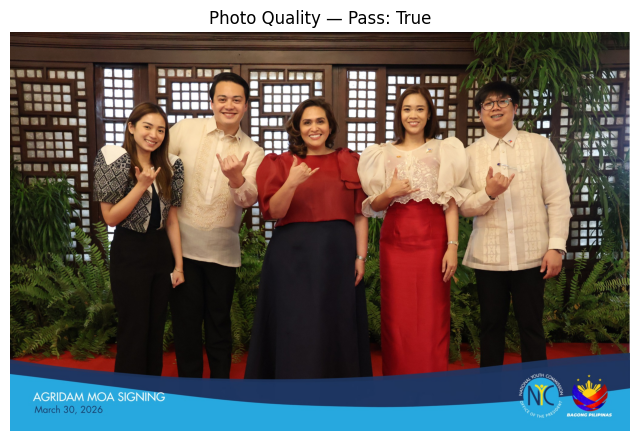

{ 'details': { 'brightness': 77.7,
               'mean_saturation': 112.2,
               'resolution': '2048x1317 (required at least 1080x1080)'},
  'label': 'Photo quality OK',
  'level': 'warning',
  'pass': True,
  'remark': 'OK'}


In [14]:
photo_image = cv2.imread('test_set/images/test_2.jpg')
assert photo_image is not None, 'Failed to load photo test image'

photo_result = check_photo_quality(photo_image)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(photo_image, cv2.COLOR_BGR2RGB))
plt.title(f'Photo Quality — Pass: {photo_result["pass"]}')
plt.axis('off')
plt.show()

pp.pprint(photo_result)


## Logo Order Check

Runs for all post types. Correct order: NYC leftmost → SK/YORP (if required) → BP rightmost.

Uses mock detected dicts to test order logic without needing real images.

In [15]:
def make_mock_box(x0, y0, x1, y1):
    box = types.SimpleNamespace()
    box.xyxy = torch.tensor([[x0, y0, x1, y1]], dtype=torch.float32)
    mock_entry = types.SimpleNamespace()
    mock_entry.xyxy = box.xyxy
    return mock_entry

# ── Test 1: Correct order NYC → SK → BP ──
mock_correct = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(10,  10, 80,  80)},
    'bp':   {'status': 'correct', 'conf': 0.88, 'box': make_mock_box(900, 10, 980, 80)},
    'sk':   {'status': 'correct', 'conf': 0.80, 'box': make_mock_box(450, 10, 530, 80)},
    'yorp': None,
}
r1 = check_logo_order(mock_correct, collaborators=['sk'])
print('Test 1 — NYC → SK → BP (expect PASS):')
pp.pprint(r1)
assert r1['pass'], 'Expected PASS'


Test 1 — NYC → SK → BP (expect PASS):
{ 'details': { 'order': 'NYC → SK → BP',
               'positions': { 'bp': np.float64(940.0),
                              'nyc': np.float64(45.0),
                              'sk': np.float64(490.0)}},
  'label': 'Logo order OK',
  'level': 'error',
  'pass': True,
  'remark': 'OK'}


In [16]:
# ── Test 2: Wrong order — SK is left of NYC ──
mock_wrong = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(200, 10, 280, 80)},
    'bp':   {'status': 'correct', 'conf': 0.88, 'box': make_mock_box(900, 10, 980, 80)},
    'sk':   {'status': 'correct', 'conf': 0.80, 'box': make_mock_box(10,  10, 90,  80)},
    'yorp': None,
}
r2 = check_logo_order(mock_wrong, collaborators=['sk'])
print('Test 2 — SK left of NYC (expect FAIL):')
pp.pprint(r2)
assert not r2['pass'], 'Expected FAIL'


Test 2 — SK left of NYC (expect FAIL):
{ 'details': { 'order': 'SK → NYC → BP',
               'positions': { 'bp': np.float64(940.0),
                              'nyc': np.float64(240.0),
                              'sk': np.float64(50.0)}},
  'label': 'Logo order issues',
  'level': 'error',
  'pass': False,
  'remark': 'NYC should be leftmost | SK should be to the right of NYC'}


In [17]:
# ── Test 3: Missing BP ──
mock_no_bp = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(10, 10, 80, 80)},
    'bp':   None,
    'sk':   None,
    'yorp': None,
}
r3 = check_logo_order(mock_no_bp, collaborators=[])
print('Test 3 — Missing BP (expect FAIL):')
pp.pprint(r3)
assert not r3['pass'], 'Expected FAIL'


Test 3 — Missing BP (expect FAIL):
{ 'details': {},
  'label': 'Cannot check logo order',
  'level': 'error',
  'pass': False,
  'remark': 'Missing NYC or BP logo prevents order validation'}


## Full Report — `generate_report()`

Runs the full pipeline: logo detection → OCR (on original image with logo boxes masked) → readability → OCR reliability gate → watermark → spelling → SGD → photo quality → overall verdict.

Change `IMAGE_PATH` and `post_type` to test different scenarios.

In [18]:
def print_audit(audit):
    print('=' * 60)
    print(f"OVERALL: {audit.get('overall', 'N/A')}  |  POST TYPE: {audit.get('post_type', 'N/A')}")
    print('=' * 60)

    # LOGOS
    logos = audit.get('logos', {})
    print(f"\n[LOGOS] {logos.get('label')} | Pass: {logos.get('pass')} | Level: {logos.get('level')}")
    for l in logos.get('details', {}).get('logos', []):
        print(f"  - {l['logo']}: {l['status']} (conf: {l['confidence']}) | Pass: {l['pass']}")

    # LOGO ORDER
    order = audit.get('logo_order', {})
    print(f"\n[LOGO ORDER] {order.get('label')} | Pass: {order.get('pass')} | Level: {order.get('level')}")
    details = order.get('details', {})
    print(f"  Order: {details.get('order')}")

    # PUBMAT QUALITY
    quality = audit.get('pubmat_quality', {})
    print(f"\n[PUBMAT QUALITY] {quality.get('label')} | Pass: {quality.get('pass')} | Level: {quality.get('level')}")
    for k, v in quality.get('details', {}).items():
        print(f"  {k}: {v}")

    # READABILITY
    readability = audit.get('readability')
    if readability:
        print(f"\n[READABILITY] {readability.get('label')} | Pass: {readability.get('pass')} | Level: {readability.get('level')}")
        print(f"  {readability.get('remark')}")

    # WATERMARK
    watermark = audit.get('watermark')
    if watermark:
        print(f"\n[WATERMARK] {watermark.get('label')} | Pass: {watermark.get('pass')} | Level: {watermark.get('level')}")
        if watermark.get('missing'):
            print(f"  Missing: {watermark['missing']}")
        if not watermark.get('pass') and watermark.get('level') == 'error' and 'skipped' in watermark.get('label','').lower():
            print(f"  ⚠ {watermark.get('remark')}")

    # SPELLING (warning)
    spelling = audit.get('spelling')
    if spelling:
        print(f"\n[SPELLING ⚠ warning] {spelling.get('label')} | Pass: {spelling.get('pass')}")
        errors = spelling.get('details', {}).get('errors', [])
        if errors:
            for e in errors:
                print(f"  - '{e['word']}' → suggestions: {list(e['suggestions'])[:3]}")
        elif 'skipped' in spelling.get('label', '').lower():
            print(f"  {spelling.get('remark')}")
        else:
            print('  No spelling errors detected')

    # SGD
    sgd = audit.get('sgd')
    if sgd:
        print(f"\n[SGD] {sgd.get('label')} | Pass: {sgd.get('pass')} | Level: {sgd.get('level')}")

    # PHOTO QUALITY (warning)
    photo = audit.get('photo_quality')
    if photo:
        print(f"\n[PHOTO QUALITY ⚠ warning] {photo.get('label')} | Pass: {photo.get('pass')}")
        for k, v in photo.get('details', {}).items():
            print(f"  {k}: {v}")

    print('=' * 60)


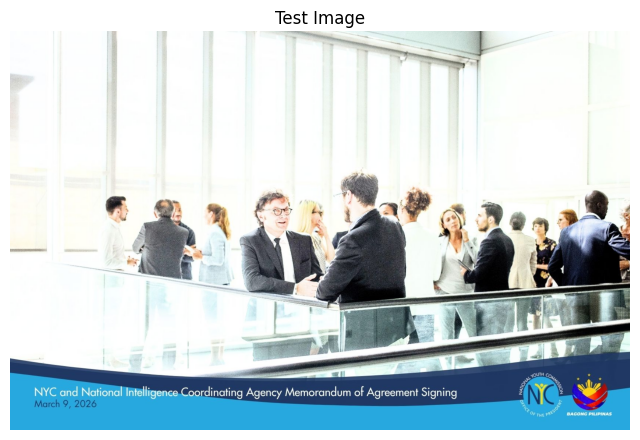

In [24]:
FULL_IMAGE_PATH = 'test_set/images/test_14.jpg'
full_image = cv2.imread(FULL_IMAGE_PATH)
assert full_image is not None, f'Failed to load: {FULL_IMAGE_PATH}'

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(full_image, cv2.COLOR_BGR2RGB))
plt.title('Test Image')
plt.axis('off')
plt.show()


In [25]:
full_report, annotated = generate_report(
    full_image,
    logo_model,
    post_type='photo',    # change to test other post types
    collaborators=[],    # add 'sk' or 'yorp' if needed
)

pp.pprint(full_report)



0: 544x800 1 NYC_Correct, 1 BP_Correct, 79.9ms
Speed: 3.6ms preprocess, 79.9ms inference, 1.8ms postprocess per image at shape (1, 3, 544, 800)
{ 'logo_order': { 'details': { 'order': 'NYC → BP',
                               'positions': { 'bp': np.float64(1569.0),
                                              'nyc': np.float64(1438.0)}},
                  'label': 'Logo order OK',
                  'level': 'error',
                  'pass': True,
                  'remark': 'OK'},
  'logos': { 'details': { 'logos': [ { 'confidence': 0.967,
                                       'detected': True,
                                       'level': 'error',
                                       'logo': 'NYC',
                                       'pass': True,
                                       'remark': 'OK',
                                       'status': 'Correct'},
                                     { 'confidence': 0.949,
                                       'detected': T

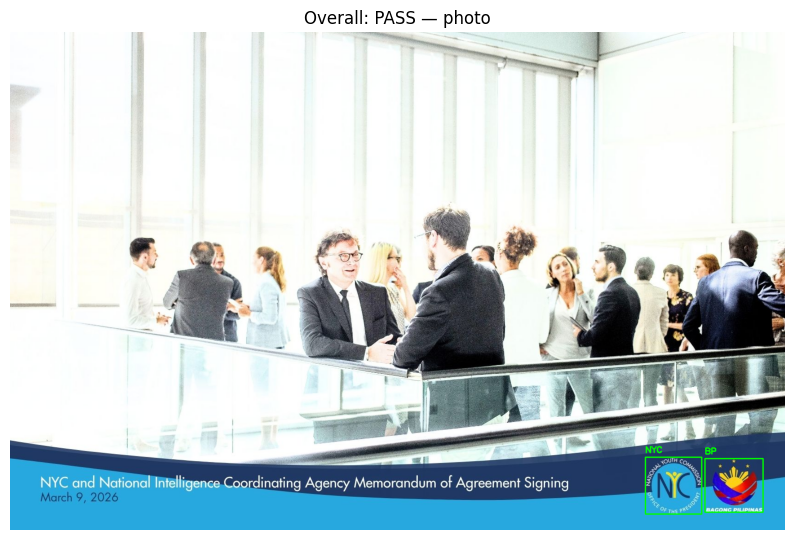

In [26]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Overall: {full_report['overall']} — {full_report['post_type']}")
plt.axis('off')
plt.show()


In [27]:
print_audit(full_report)


OVERALL: PASS  |  POST TYPE: photo

[LOGOS] All logos OK | Pass: True | Level: error
  - NYC: Correct (conf: 0.967) | Pass: True
  - BP: Correct (conf: 0.949) | Pass: True

[LOGO ORDER] Logo order OK | Pass: True | Level: error
  Order: NYC → BP

[PUBMAT QUALITY] Pubmat quality OK | Pass: True | Level: error
  Resolution: 1680x1080
  Blur Metric: 1265.0
  Contrast Metric: 76.2

[PHOTO QUALITY ⚠ warning] Photo quality issues | Pass: False
  resolution: 1680x1080 (required at least 1080x1080)
  brightness: 216.5
  mean_saturation: 16.4


## OCR Reliability Gate — Manual Test

Verifies that when readability fails or no text is detected:
- `watermark` is set to FAIL with `level='error'` and a manual review remark
- `spelling` is skipped with `pass=True` and `level='warning'`

This mirrors the gate logic inside `generate_report()`.

In [23]:
# Simulate an unreadable image by passing an all-white image
blank_image = np.ones((1080, 1080, 3), dtype=np.uint8) * 255

blank_report, _ = generate_report(
    blank_image,
    logo_model,
    post_type='news',
    collaborators=[],
)

print('Blank image report (expect watermark=FAIL error, spelling=skipped warning):')
wm = blank_report.get('watermark', {})
sp = blank_report.get('spelling', {})
print(f"  watermark → pass={wm.get('pass')} | level={wm.get('level')} | label='{wm.get('label')}'")
print(f"  spelling  → pass={sp.get('pass')} | level={sp.get('level')} | label='{sp.get('label')}'")
print(f"  overall   → {blank_report.get('overall')}")

assert wm.get('level') == 'error',   'Watermark should be error level when OCR unreliable'
assert wm.get('pass')  == False,     'Watermark should FAIL when OCR unreliable'
assert sp.get('pass')  == True,      'Spelling should pass=True when skipped'
assert sp.get('level') == 'warning', 'Spelling should be warning level when skipped'
print('\nAll OCR reliability gate assertions passed.')



0: 800x800 (no detections), 47.6ms
Speed: 4.6ms preprocess, 47.6ms inference, 1.5ms postprocess per image at shape (1, 3, 800, 800)
Blank image report (expect watermark=FAIL error, spelling=skipped warning):
  watermark → pass=False | level=error | label='Watermark check skipped'
  spelling  → pass=True | level=warning | label='Spelling check skipped'
  overall   → FAIL

All OCR reliability gate assertions passed.
